In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split


In [7]:
df = pd.read_csv("D:\Mini Project\data\CVD Dataset.csv")

In [8]:
df.columns

Index(['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI',
       'Abdominal Circumference (cm)', 'Blood Pressure (mmHg)',
       'Total Cholesterol (mg/dL)', 'HDL (mg/dL)',
       'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD', 'Height (cm)',
       'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
       'Blood Pressure Category', 'Estimated LDL (mg/dL)', 'CVD Risk Score',
       'CVD Risk Level'],
      dtype='str')

Dropping redundant columns (Height (m))

In [9]:
df = df.drop('Height (cm)', axis=1)

In [10]:
df.dtypes

Sex                                 str
Age                             float64
Weight (kg)                     float64
Height (m)                      float64
BMI                             float64
Abdominal Circumference (cm)    float64
Blood Pressure (mmHg)               str
Total Cholesterol (mg/dL)       float64
HDL (mg/dL)                     float64
Fasting Blood Sugar (mg/dL)     float64
Smoking Status                      str
Diabetes Status                     str
Physical Activity Level             str
Family History of CVD               str
Waist-to-Height Ratio           float64
Systolic BP                     float64
Diastolic BP                    float64
Blood Pressure Category             str
Estimated LDL (mg/dL)           float64
CVD Risk Score                  float64
CVD Risk Level                      str
dtype: object

In [11]:
df.head()

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Diabetes Status,Physical Activity Level,Family History of CVD,Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Y,Low,N,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,Y,High,Y,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,N,High,Y,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,N,High,Y,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,Y,High,N,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY


In [12]:
df.isna().sum()

Sex                              0
Age                             78
Weight (kg)                     81
Height (m)                      67
BMI                             64
Abdominal Circumference (cm)    67
Blood Pressure (mmHg)            0
Total Cholesterol (mg/dL)       73
HDL (mg/dL)                     80
Fasting Blood Sugar (mg/dL)     67
Smoking Status                   0
Diabetes Status                  0
Physical Activity Level          0
Family History of CVD            0
Waist-to-Height Ratio           79
Systolic BP                     71
Diastolic BP                    82
Blood Pressure Category          0
Estimated LDL (mg/dL)           69
CVD Risk Score                  70
CVD Risk Level                   0
dtype: int64

From above, we can observe that there are a few nan or missing values in the dataset

In [13]:
numCol = df.select_dtypes(['number']).columns
strCol = df.select_dtypes(['object']).columns
numImputer = SimpleImputer(strategy='mean')
df[numCol] = numImputer.fit_transform(df[numCol])
strImputer = SimpleImputer(strategy='most_frequent')
df[strCol] = strImputer.fit_transform(df[strCol])


C:\Users\Maithreyi\AppData\Local\Temp\ipykernel_2516\1683058921.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  strCol = df.select_dtypes(['object']).columns


In [14]:
df.isna().sum()

Sex                             0
Age                             0
Weight (kg)                     0
Height (m)                      0
BMI                             0
Abdominal Circumference (cm)    0
Blood Pressure (mmHg)           0
Total Cholesterol (mg/dL)       0
HDL (mg/dL)                     0
Fasting Blood Sugar (mg/dL)     0
Smoking Status                  0
Diabetes Status                 0
Physical Activity Level         0
Family History of CVD           0
Waist-to-Height Ratio           0
Systolic BP                     0
Diastolic BP                    0
Blood Pressure Category         0
Estimated LDL (mg/dL)           0
CVD Risk Score                  0
CVD Risk Level                  0
dtype: int64

We have cleaned the missing values and replaced it with median and most frequent values for numeric and str values respectively

In [15]:
strCol

Index(['Sex', 'Blood Pressure (mmHg)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD',
       'Blood Pressure Category', 'CVD Risk Level'],
      dtype='str')

In [16]:
df[strCol]


,Sex,Blood Pressure (mmHg),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Blood Pressure Category,CVD Risk Level
0,F,125/79,N,Y,Low,N,Elevated,INTERMEDIARY
1,F,139/70,Y,Y,High,Y,Hypertension Stage 1,HIGH
2,M,104/77,N,N,High,Y,Normal,INTERMEDIARY
3,M,140/83,N,N,High,Y,Hypertension Stage 1,INTERMEDIARY
4,F,144/83,Y,Y,High,N,Hypertension Stage 1,INTERMEDIARY
...,...,...,...,...,...,...,...,...
1524,F,119/66,N,N,Moderate,Y,Normal,LOW
1525,F,102/115,Y,N,Low,N,Hypertension Stage 2,INTERMEDIARY
1526,M,150/90,N,Y,High,N,Hypertension Stage 2,INTERMEDIARY
1527,M,112/63,N,N,High,Y,Normal,INTERMEDIARY


In [17]:
df['Sex']=df['Sex'].replace({'F':0, 'M':1})


In [18]:
bp_split = df['Blood Pressure (mmHg)'].str.split('/', expand=True)
systolic = pd.to_numeric(bp_split[0], errors='coerce')
diastolic = pd.to_numeric(bp_split[1], errors='coerce')
df['Blood Pressure (mmHg)'] = systolic/diastolic

In [19]:
df.rename(columns={'Blood Pressure (mmHg)': 'Blood Pressure Ratio'}, inplace=True)

In [20]:
df['Smoking Status'] = df['Smoking Status'].replace({'N':0, 'Y':1})
df['Diabetes Status'] = df['Diabetes Status'].replace({'N':0, 'Y':1})
df['Physical Activity Level'] = df['Physical Activity Level'].replace({'Low':0, 'Moderate':1, 'High':2})
df['Family History of CVD'] = df['Family History of CVD'].replace({'N':0, 'Y':1})
df['Blood Pressure Category'] = df['Blood Pressure Category'].replace({'Normal':0, 'Hypertension Stage 1':1, 'Hypertension Stage 2': 2, 'Elevated': 3})
df['CVD Risk Level'] = df['CVD Risk Level'].replace({'LOW': 0, 'INTERMEDIARY':1, 'HIGH': 2})

In [21]:
df

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure Ratio,Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Diabetes Status,Physical Activity Level,Family History of CVD,Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,0,32.0000,69.100000,1.710,23.600000,86.200,1.582278,248.0,78.0,111.000000,...,1,0,0,0.504,125.0,79.0,3,140.0,17.930,1
1,0,55.0000,118.700000,1.690,41.600000,82.500,1.985714,162.0,50.0,135.000000,...,1,2,1,0.488,139.0,70.0,1,82.0,20.510,2
2,1,47.0255,85.917427,1.830,26.900000,106.700,1.350649,103.0,73.0,114.000000,...,0,2,1,0.583,104.0,77.0,0,0.0,12.640,1
3,1,44.0000,108.300000,1.800,33.400000,96.600,1.686747,134.0,46.0,91.000000,...,0,2,1,0.537,140.0,83.0,1,58.0,16.360,1
4,0,32.0000,99.500000,1.860,28.800000,102.700,1.734940,146.0,64.0,141.000000,...,1,2,0,0.552,144.0,83.0,1,52.0,17.880,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1524,0,40.0000,72.070000,1.889,28.465997,95.326,1.803030,157.0,60.0,93.000000,...,0,1,1,0.505,119.0,66.0,0,67.0,14.300,0
1525,0,78.0000,85.877000,1.825,24.426000,112.340,0.886957,241.0,84.0,117.485636,...,0,0,0,0.616,102.0,115.0,2,127.0,14.805,1
1526,1,39.0000,98.626000,1.521,20.055000,77.193,1.666667,237.0,82.0,147.000000,...,1,2,0,0.507,150.0,90.0,2,125.0,18.251,1
1527,1,71.0000,116.163000,1.841,29.279000,114.197,1.777778,193.0,84.0,123.000000,...,0,2,1,0.620,112.0,63.0,0,79.0,15.316,1


In [22]:
df.dtypes

Sex                              object
Age                             float64
Weight (kg)                     float64
Height (m)                      float64
BMI                             float64
Abdominal Circumference (cm)    float64
Blood Pressure Ratio            float64
Total Cholesterol (mg/dL)       float64
HDL (mg/dL)                     float64
Fasting Blood Sugar (mg/dL)     float64
Smoking Status                   object
Diabetes Status                  object
Physical Activity Level          object
Family History of CVD            object
Waist-to-Height Ratio           float64
Systolic BP                     float64
Diastolic BP                    float64
Blood Pressure Category          object
Estimated LDL (mg/dL)           float64
CVD Risk Score                  float64
CVD Risk Level                   object
dtype: object

In [23]:
obj_cols = df.select_dtypes(include=['object']).columns
for col in obj_cols:
    df[col] = pd.to_numeric(df[col],errors='coerce')
df


,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure Ratio,Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Diabetes Status,Physical Activity Level,Family History of CVD,Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,0,32.0000,69.100000,1.710,23.600000,86.200,1.582278,248.0,78.0,111.000000,...,1,0,0,0.504,125.0,79.0,3,140.0,17.930,1
1,0,55.0000,118.700000,1.690,41.600000,82.500,1.985714,162.0,50.0,135.000000,...,1,2,1,0.488,139.0,70.0,1,82.0,20.510,2
2,1,47.0255,85.917427,1.830,26.900000,106.700,1.350649,103.0,73.0,114.000000,...,0,2,1,0.583,104.0,77.0,0,0.0,12.640,1
3,1,44.0000,108.300000,1.800,33.400000,96.600,1.686747,134.0,46.0,91.000000,...,0,2,1,0.537,140.0,83.0,1,58.0,16.360,1
4,0,32.0000,99.500000,1.860,28.800000,102.700,1.734940,146.0,64.0,141.000000,...,1,2,0,0.552,144.0,83.0,1,52.0,17.880,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1524,0,40.0000,72.070000,1.889,28.465997,95.326,1.803030,157.0,60.0,93.000000,...,0,1,1,0.505,119.0,66.0,0,67.0,14.300,0
1525,0,78.0000,85.877000,1.825,24.426000,112.340,0.886957,241.0,84.0,117.485636,...,0,0,0,0.616,102.0,115.0,2,127.0,14.805,1
1526,1,39.0000,98.626000,1.521,20.055000,77.193,1.666667,237.0,82.0,147.000000,...,1,2,0,0.507,150.0,90.0,2,125.0,18.251,1
1527,1,71.0000,116.163000,1.841,29.279000,114.197,1.777778,193.0,84.0,123.000000,...,0,2,1,0.620,112.0,63.0,0,79.0,15.316,1


In [24]:
df.dtypes

Sex                               int64
Age                             float64
Weight (kg)                     float64
Height (m)                      float64
BMI                             float64
Abdominal Circumference (cm)    float64
Blood Pressure Ratio            float64
Total Cholesterol (mg/dL)       float64
HDL (mg/dL)                     float64
Fasting Blood Sugar (mg/dL)     float64
Smoking Status                    int64
Diabetes Status                   int64
Physical Activity Level           int64
Family History of CVD             int64
Waist-to-Height Ratio           float64
Systolic BP                     float64
Diastolic BP                    float64
Blood Pressure Category           int64
Estimated LDL (mg/dL)           float64
CVD Risk Score                  float64
CVD Risk Level                    int64
dtype: object

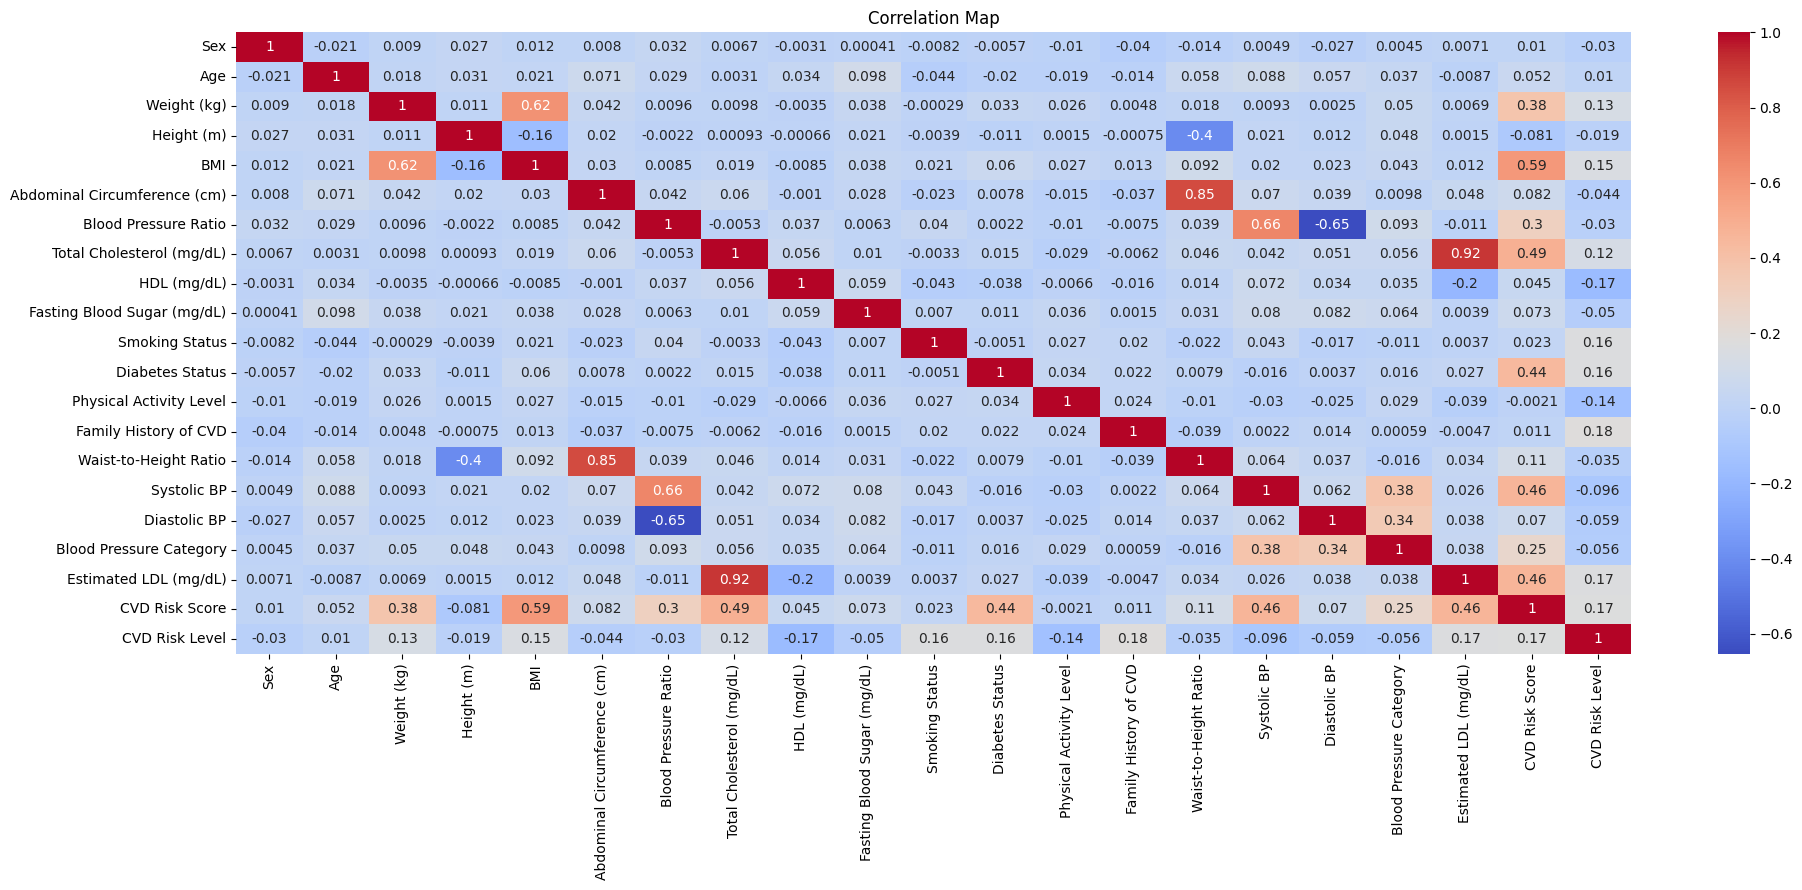

In [25]:
plt.figure(figsize=(20,9))
sns.heatmap(df.corr(),cmap='coolwarm',annot=True)
plt.title("Correlation Map")
plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

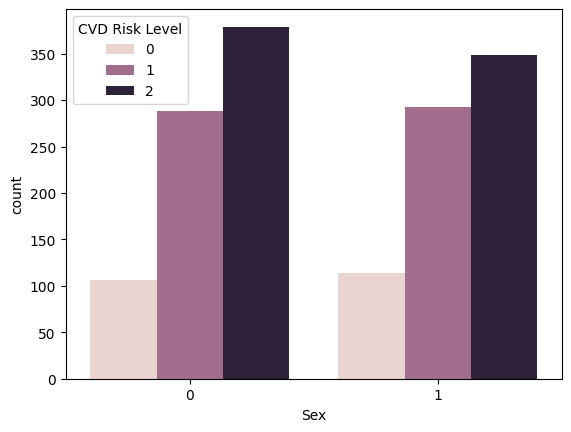

In [26]:
sns.countplot(x='Sex',data=df,hue='CVD Risk Level')

<Axes: xlabel='CVD Risk Score', ylabel='Age'>

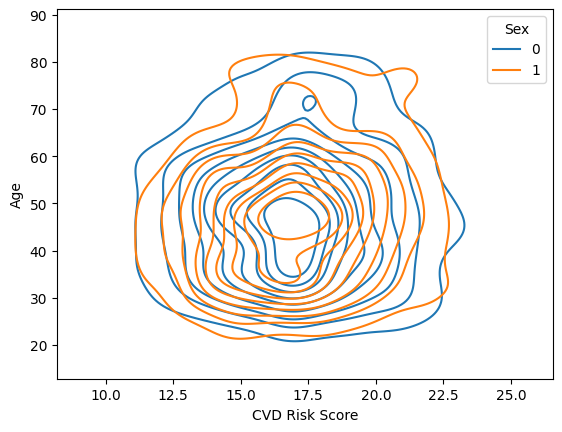

In [27]:
sns.kdeplot(x='CVD Risk Score',y='Age',data=df,hue='Sex')

In [28]:
y = df['CVD Risk Score']
X = df.drop(columns=['CVD Risk Score','CVD Risk Level'])
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
from boruta import BorutaPy
from xgboost import XGBRegressor

In [30]:
boruta = BorutaPy(XGBRegressor(), n_estimators='auto', random_state=42)
boruta.fit(X_train.values,y_train.values)

,estimator,"XGBRegressor(...ree=None, ...)"
,n_estimators,'auto'
,perc,100
,alpha,0.05
,two_step,True
,max_iter,100
,random_state,RandomState(M... 0x1DF3DE2A740
,verbose,0
,early_stopping,False
,n_iter_no_change,20
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'


In [31]:
X_train_reduced = X_train.loc[:,boruta.support_]
X_test_reduced = X_test.loc[:,boruta.support_]

In [32]:
model = XGBRegressor(random_state=42)
model.fit(X_train_reduced, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [33]:
import shap

d:\Mini Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


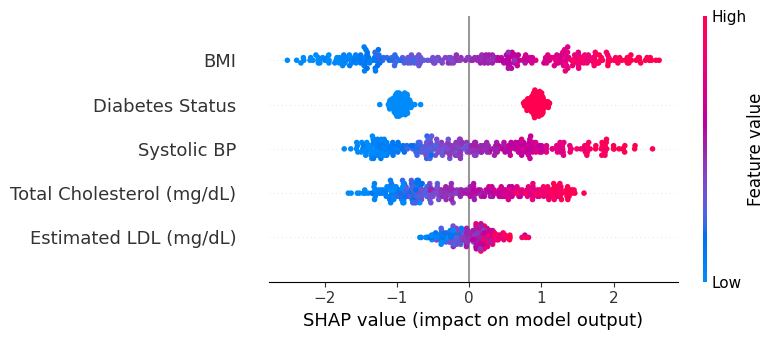

In [34]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_reduced)
shap.summary_plot(shap_values, X_test_reduced)

In [35]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

In [36]:
predictions = model.predict(X_test_reduced)

In [37]:
print(f"R2 score: {r2_score(y_test,predictions): .3f}")
print(f"MSE: {mean_squared_error(y_test, predictions): .2f}%")

R2 score:  0.923
MSE:  0.53%


Testing feature importance with respect to gender specificity

Extracting feature importance with shap for only women

In [38]:
df_women = df.copy()
df_women=df_women[df_women['Sex']==0]
y_w = df_women['CVD Risk Score']
X_w = df_women.drop(columns=['CVD Risk Score','CVD Risk Level'])
X_test_w, X_train_w, y_test_w, y_train_w = train_test_split(X_w,y_w,test_size=0.2,random_state=42)

In [39]:
boruta_w = BorutaPy(XGBRegressor(), n_estimators='auto', random_state=42)
boruta_w.fit(X_train_w.values,y_train_w.values)

,estimator,"XGBRegressor(...ree=None, ...)"
,n_estimators,'auto'
,perc,100
,alpha,0.05
,two_step,True
,max_iter,100
,random_state,RandomState(M... 0x1DF3D766640
,verbose,0
,early_stopping,False
,n_iter_no_change,20
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'


In [85]:
X_train_reduced_w = X_train_w.loc[:,boruta_w.support_]
X_test_reduced_w = X_test_w.loc[:,boruta_w.support_]

In [41]:
model_w = XGBRegressor(random_state=42)
model_w.fit(X_train_reduced_w, y_train_w)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

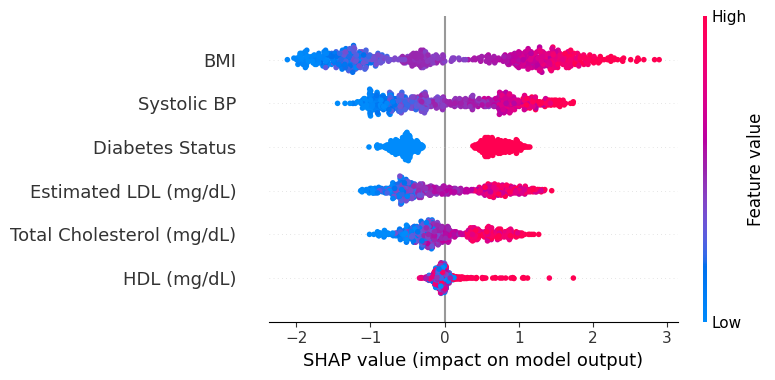

In [42]:
explainer_w = shap.TreeExplainer(model_w)
shap_values_w = explainer_w.shap_values(X_test_reduced_w)
shap.summary_plot(shap_values_w, X_test_reduced_w)

In [43]:
predictions_w = model_w.predict(X_test_reduced_w)
print(f"R2 score: {r2_score(y_test_w,predictions_w): .3f}")
print(f"MSE: {mean_squared_error(y_test_w, predictions_w): .2f}%")


R2 score:  0.804
MSE:  1.12%


Checking for only - men values

In [44]:
df_men = df.copy()
df_men=df_men[df_men['Sex']==1]
y_m = df_men['CVD Risk Score']
X_m = df_men.drop(columns=['CVD Risk Score','CVD Risk Level'])
X_test_m, X_train_m, y_test_m, y_train_m = train_test_split(X_m,y_m,test_size=0.2,random_state=42)

In [45]:
boruta_m = BorutaPy(XGBRegressor(), n_estimators='auto', random_state=42)
boruta_m.fit(X_train_m.values,y_train_m.values)

,estimator,"XGBRegressor(...ree=None, ...)"
,n_estimators,'auto'
,perc,100
,alpha,0.05
,two_step,True
,max_iter,100
,random_state,RandomState(M... 0x1DF42B4C340
,verbose,0
,early_stopping,False
,n_iter_no_change,20
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'


In [46]:
X_train_reduced_m = X_train_m.loc[:,boruta_m.support_]
X_test_reduced_m = X_test_m.loc[:,boruta_m.support_]

In [47]:
model_m = XGBRegressor(random_state=42)
model_m.fit(X_train_reduced_m, y_train_m)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

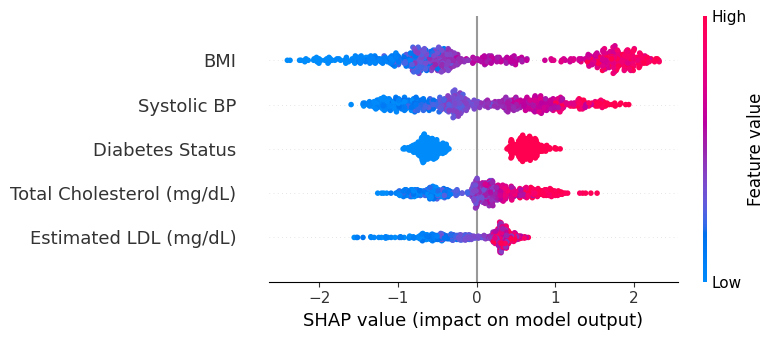

In [48]:
explainer_m = shap.TreeExplainer(model_m)
shap_values_m = explainer_m.shap_values(X_test_reduced_m)
shap.summary_plot(shap_values_m, X_test_reduced_m)

In [49]:
predictions_m = model_m.predict(X_test_reduced_m)
print(f"R2 score: {r2_score(y_test_m,predictions_m): .3f}")
print(f"MSE: {mean_squared_error(y_test_m, predictions_m): .2f}%")

R2 score:  0.807
MSE:  1.10%


In [51]:
import joblib

In [52]:
joblib.dump(model_w,'Fmodel.joblib')

['Fmodel.joblib']

In [47]:
fmodel = joblib.load('Fmodel.joblib')

In [50]:
predictions = fmodel.predict(X_test_reduced_w)
predictions

array([17.250992 , 12.562421 , 13.819193 , 17.040434 , 17.084509 ,
       16.489159 , 14.949725 , 16.273216 , 16.209297 , 15.429202 ,
       16.292063 , 16.607763 , 15.648325 , 14.517409 , 16.586493 ,
       15.816698 , 17.871216 , 15.094841 , 16.169167 , 13.204337 ,
       15.69498  , 16.727312 , 14.188544 , 19.713058 , 15.103302 ,
       17.88128  , 19.299244 , 17.71278  , 17.038265 , 15.468726 ,
       17.03705  , 17.493116 , 19.964397 , 15.613754 , 17.40432  ,
       16.345514 , 13.63737  , 18.65692  , 20.597729 , 18.794916 ,
       17.543081 , 16.85407  , 17.219254 , 12.72181  , 14.46275  ,
       12.481186 , 16.505377 , 16.496153 , 17.15235  , 20.343239 ,
       17.890774 , 16.371536 , 17.910316 , 20.640089 , 17.832994 ,
       15.391581 , 17.526493 , 17.884138 , 18.052343 , 16.829357 ,
       17.776058 , 17.57388  , 16.608566 , 19.171852 , 16.409615 ,
       18.462805 , 16.20261  , 16.356195 , 16.881332 , 16.75683  ,
       17.259789 , 20.782825 , 17.04102  , 15.999295 , 16.4477

In [51]:
y.describe()

count    1529.000000
mean       16.960925
std         2.379735
min        10.530000
25%        15.290000
50%        16.960925
75%        18.510000
max        24.170000
Name: CVD Risk Score, dtype: float64

<Axes: xlabel='CVD Risk Score', ylabel='Count'>

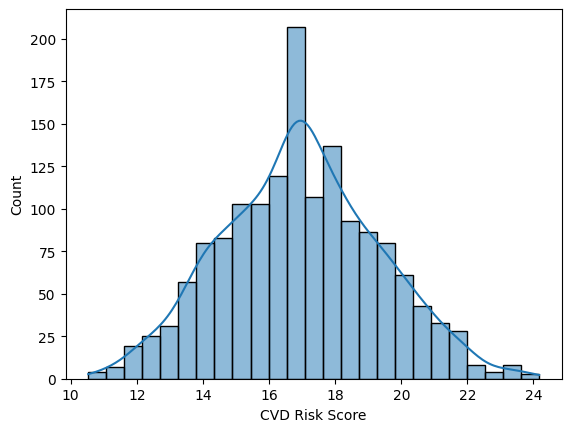

In [52]:
sns.histplot(y,kde=True)

In [83]:
df_women['Age'].mean()

np.float64(47.27424901236868)